# Trial 1 (Leakage-Free) — Fold-Local Fine-tuning + Fold-Local PCA

This notebook removes validation leakage by design:
1. Fine-tune the sentence encoder **inside each CV fold** using fold-train only.
2. Fit PCA **inside each fold** on fold-train features only.
3. Never use fold-validation rows to fit trainable transforms.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'sentence-transformers', 'transformers', 'scikit-learn', 'tqdm'], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'sentence-transformers', 'transformers', 'scikit-learn', 'tqdm'], returncode=0)

In [2]:
import json, hashlib, warnings, random
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import CrossEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA = Path('/kaggle/input/datasets/shubhadeepmandal/inlp-project')

CFG = dict(
    mpnet_model='sentence-transformers/all-mpnet-base-v2',
    ce_model='cross-encoder/nli-deberta-v3-base',  # upgraded from -small
    max_seq_len=256,
    mpnet_max_len=128,
    ft_epochs=6,
    ft_batch_size=24,
    ft_lr=2e-5,
    ft_ranking_w=0.5,
    ft_warmup_ratio=0.1,
    pca_components=96,
    batch_size=32,
    n_folds=5,
    mlp_hidden1=512,
    mlp_hidden2=128,
    mlp_dropout=0.3,
    mlp_lr=8e-4,
    mlp_weight_decay=3e-4,
    mlp_epochs=60,
    pairwise_margin=0.5,
    pairwise_w=0.3,
    mse_w=0.2,
    rank_blend_w=0.15,
    swa_start_ratio=0.75,   # NEW: start SWA after this fraction of MLP epochs
)

Device: cuda


In [3]:
def load_json(path):
    with open(path) as f:
        raw = json.load(f)
    rows = []
    for k, v in raw.items():
        row = dict(v)
        row['idx'] = int(k)
        rows.append(row)
    df = pd.DataFrame(rows).sort_values('idx').reset_index(drop=True)
    df['ending'] = df['ending'].fillna('').apply(str).str.strip()
    return df

def make_setup_id(row):
    key = (f"{row['homonym']}||{row['precontext']}"
           f"||{row['sentence']}||{row['ending']}")
    return hashlib.md5(key.encode()).hexdigest()[:10]

def build_story(row):
    base = row['precontext'].strip() + ' ' + row['sentence'].strip()
    if row['ending']:
        base += ' ' + row['ending']
    return base

def build_ending_text(row):
    # Sense-resolving fragment: ending if present, else the ambiguous sentence
    return row['ending'].strip() if row['ending'] else row['sentence'].strip()

def build_ambiguous_text(row):
    # Just the ambiguous sentence (no precontext, no ending)
    return row['sentence'].strip()

def make_target_dist(row):
    choices = row['choices']
    nonsens = row.get('nonsensical', [False] * len(choices))
    valid = [c for c, ns in zip(choices, nonsens) if not ns]
    if not valid:
        valid = choices
    counts = Counter(int(c) for c in valid)
    dist = np.array([counts.get(i, 0) for i in range(1, 6)], dtype=np.float32)
    return dist / dist.sum()

train_df = load_json(DATA / 'train.json')
dev_df   = load_json(DATA / 'dev.json')
test_df  = load_json(DATA / 'test.json')

for df in (train_df, dev_df, test_df):
    df['setup_id']       = df.apply(make_setup_id, axis=1)
    df['story_text']     = df.apply(build_story, axis=1)
    df['ending_text']    = df.apply(build_ending_text, axis=1)    # NEW
    df['ambiguous_text'] = df.apply(build_ambiguous_text, axis=1) # NEW
    df['meaning_text']   = df['judged_meaning'] + '. For example: ' + df['example_sentence']

for df in (train_df, dev_df):
    df['target_dist'] = df.apply(make_target_dist, axis=1)

traindev_df = pd.concat([train_df, dev_df], ignore_index=True)
traindev_df['target_dist'] = traindev_df.apply(make_target_dist, axis=1)
print(f'Train+Dev={len(traindev_df)} | Test={len(test_df)}')

Train+Dev=2868 | Test=930


In [4]:
import copy
import math

class SentenceEncoder(nn.Module):
    def __init__(self, model_name, max_len=128):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name)
        self.max_len = max_len

    @staticmethod
    def mean_pool(last_hidden, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        return (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def encode_texts(self, texts, device):
        enc = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.max_len, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        out = self.transformer(**enc)
        emb = self.mean_pool(out.last_hidden_state, enc['attention_mask'])
        return F.normalize(emb, dim=-1)

    def forward(self, stories, meanings, device):
        hs = self.encode_texts(stories, device)
        hm = self.encode_texts(meanings, device)
        return hs, hm

print('Loading base mpnet encoder once (folds clone from this)...')
BASE_ENCODER = SentenceEncoder(CFG['mpnet_model'], max_len=CFG['mpnet_max_len']).to('cpu')

def ft_pairwise_loss(cos_sims, targets, setup_ids, margin=0.1):
    groups = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    loss = torch.tensor(0.0, device=cos_sims.device)
    n_pair = 0
    for idxs in groups.values():
        for a in idxs:
            for b in idxs:
                if targets[a] > targets[b] + 0.05:
                    loss = loss + F.relu(margin - (cos_sims[a] - cos_sims[b]))
                    n_pair += 1
    return loss / max(n_pair, 1)

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, last_epoch=-1):
    # Cosine annealing LR schedule with linear warmup
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch)

def finetune_encoder_fold(df_train, df_val, cfg, device, fold_tag=''):
    enc = copy.deepcopy(BASE_ENCODER).to(device)
    optimizer = torch.optim.AdamW(enc.transformer.parameters(), lr=cfg['ft_lr'], weight_decay=1e-2)

    steps_per_epoch = math.ceil(len(df_train) / cfg['ft_batch_size'])
    total_steps     = cfg['ft_epochs'] * steps_per_epoch
    warmup_steps    = int(cfg['ft_warmup_ratio'] * total_steps)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    stories_tr  = df_train['story_text'].tolist()
    meanings_tr = df_train['meaning_text'].tolist()
    sids_tr     = df_train['setup_id'].tolist()
    y_tr        = ((df_train['average'].values - 1.0) / 4.0).astype(np.float32)

    stories_v  = df_val['story_text'].tolist()
    meanings_v = df_val['meaning_text'].tolist()

    best_spear = -1.0
    best_state = None
    bs         = cfg['ft_batch_size']
    no_improve = 0
    patience   = 2

    for ep in range(1, cfg['ft_epochs'] + 1):
        enc.train()
        perm = torch.randperm(len(stories_tr)).tolist()

        for start in range(0, len(stories_tr), bs):
            idx    = perm[start:start+bs]
            tgt    = torch.tensor(y_tr[idx], dtype=torch.float32, device=device)
            sids_b = [sids_tr[i] for i in idx]
            hs, hm = enc([stories_tr[i] for i in idx], [meanings_tr[i] for i in idx], device)
            cos_sim = (hs * hm).sum(dim=-1)
            loss = F.mse_loss(cos_sim, tgt) + cfg['ft_ranking_w'] * ft_pairwise_loss(cos_sim, tgt, sids_b)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(enc.transformer.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        enc.eval()
        val_cos = []
        with torch.no_grad():
            for start in range(0, len(stories_v), 64):
                hs, hm = enc(stories_v[start:start+64], meanings_v[start:start+64], device)
                val_cos.append((hs * hm).sum(dim=-1).cpu().numpy())
        val_cos = np.concatenate(val_cos)
        val_spear, _ = spearmanr(df_val['average'].values, val_cos)
        if not np.isfinite(val_spear):
            val_spear = -1.0

        if best_state is None or val_spear > best_spear:
            best_spear = val_spear
            best_state = {k: v.cpu().clone() for k, v in enc.transformer.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        tag = f' [{fold_tag}]' if fold_tag else ''
        print(f'  FT{tag} epoch {ep}/{cfg["ft_epochs"]}  val_spear={val_spear:.4f}')

        if no_improve >= patience:
            print(f'  FT{tag} early stopping at epoch {ep}')
            break

    if best_state is not None:
        enc.transformer.load_state_dict(best_state)
    return enc

def encode_df(enc, df, device, batch=64):
    # Encode story, ending, ambiguous sentence, and meaning texts (returns 4 arrays)
    enc.eval()
    stories   = df['story_text'].tolist()
    endings   = df['ending_text'].tolist()
    ambiguous = df['ambiguous_text'].tolist()
    meanings  = df['meaning_text'].tolist()

    hs_all, hm_all, he_all, ha_all = [], [], [], []
    with torch.no_grad():
        for start in range(0, len(df), batch):
            sl = slice(start, start + batch)
            hs = enc.encode_texts(stories[sl], device)
            hm = enc.encode_texts(meanings[sl], device)
            he = enc.encode_texts(endings[sl], device)
            ha = enc.encode_texts(ambiguous[sl], device)
            hs_all.append(hs.cpu().numpy())
            hm_all.append(hm.cpu().numpy())
            he_all.append(he.cpu().numpy())
            ha_all.append(ha.cpu().numpy())
    return (np.vstack(hs_all), np.vstack(hm_all),
            np.vstack(he_all), np.vstack(ha_all))

Loading base mpnet encoder once (folds clone from this)...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
print('Loading frozen cross-encoder once...')
cross_enc = CrossEncoder(CFG['ce_model'], max_length=CFG['max_seq_len'])

def compute_ce_scores(df, desc):
    pairs = list(zip(df['story_text'].tolist(), df['judged_meaning'].tolist()))
    out = []
    for i in tqdm(range(0, len(pairs), CFG['batch_size']), desc=desc):
        p = cross_enc.predict(pairs[i:i+CFG['batch_size']], apply_softmax=True)
        out.extend(p[:, 1].tolist())
    return np.array(out, dtype=np.float32)

ce_traindev = compute_ce_scores(traindev_df, 'CE traindev')
ce_test = compute_ce_scores(test_df, 'CE test')

Loading frozen cross-encoder once...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

CE traindev:   0%|          | 0/90 [00:00<?, ?it/s]

CE test:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
def cosine_sim(a, b):
    a_n = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    b_n = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return (a_n * b_n).sum(axis=1).astype(np.float32)

def within_setup_delta(cos_arr, setup_ids):
    delta = np.zeros(len(cos_arr), dtype=np.float32)
    groups = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    for idxs in groups.values():
        m = cos_arr[idxs].mean()
        for i in idxs:
            delta[i] = cos_arr[i] - m
    return delta

def within_setup_rank(cos_arr, setup_ids):
    rank_arr = np.zeros(len(cos_arr), dtype=np.float32)
    groups = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    for idxs in groups.values():
        vals = [(cos_arr[i], i) for i in idxs]
        vals_sorted = sorted(vals, key=lambda x: x[0])
        n = len(vals_sorted)
        for rank, (_, orig_i) in enumerate(vals_sorted):
            rank_arr[orig_i] = rank / max(n - 1, 1)
    return rank_arr

def ce_delta(ce_arr, setup_ids):
    delta = np.zeros(len(ce_arr), dtype=np.float32)
    groups = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    for idxs in groups.values():
        m = ce_arr[idxs].mean()
        for i in idxs:
            delta[i] = ce_arr[i] - m
    return delta

def token_overlap_ratio(df):
    ratios = []
    for _, row in df.iterrows():
        story_tokens   = set(row['story_text'].lower().split())
        meaning_tokens = set(row['meaning_text'].lower().split())
        if len(story_tokens | meaning_tokens) == 0:
            ratios.append(0.0)
        else:
            ratios.append(len(story_tokens & meaning_tokens) / len(story_tokens | meaning_tokens))
    return np.array(ratios, dtype=np.float32)

def length_ratio(df):
    ratios = []
    for _, row in df.iterrows():
        s = len(row['story_text'].split())
        m = len(row['meaning_text'].split())
        ratios.append(s / max(m, 1))
    return np.array(ratios, dtype=np.float32)

def per_homonym_mean(df, homonym_means=None):
    # NEW: per-homonym global training mean.
    # If homonym_means is None, compute from df (fit mode).
    # Otherwise use the provided dict (transform mode).
    if homonym_means is None:
        homonym_means = df.groupby('homonym')['average'].mean().to_dict()
    vals = np.array([homonym_means.get(h, 3.0) for h in df['homonym'].tolist()],
                    dtype=np.float32)
    return vals, homonym_means

def make_features(hs, hm, he, ha, setup_ids, ce_scores,
                  df=None, pca_l1=None, pca_had=None,
                  fit=False, k=96, homonym_means=None):
    cos     = cosine_sim(hs, hm)
    cos_end = cosine_sim(he, hm)   # NEW: ending vs meaning
    cos_amb = cosine_sim(ha, hm)   # NEW: ambiguous sentence vs meaning

    dlt     = within_setup_delta(cos, setup_ids)
    ws_rank = within_setup_rank(cos, setup_ids)
    ce_dlt  = ce_delta(ce_scores, setup_ids)

    l1  = np.abs(hs - hm)
    had = hs * hm

    if fit:
        pca_l1  = PCA(n_components=k, random_state=42).fit(l1)
        pca_had = PCA(n_components=k, random_state=42).fit(had)

    l1_p  = pca_l1.transform(l1).astype(np.float32)
    had_p = pca_had.transform(had).astype(np.float32)

    # 11 scalars: cos, delta, CE, ws_rank, ce_delta, cos_end, cos_amb,
    #              tok_ratio, len_ratio, hom_mean (when df provided)
    scalar_list = [cos, dlt, ce_scores, ws_rank, ce_dlt, cos_end, cos_amb]

    if df is not None:
        tok_ratio = token_overlap_ratio(df)
        len_rat   = length_ratio(df)
        scalar_list.extend([tok_ratio, len_rat])
        hom_mean_vals, homonym_means_out = per_homonym_mean(df, homonym_means)
        scalar_list.append(hom_mean_vals)
    else:
        homonym_means_out = homonym_means

    scalars = np.stack(scalar_list, axis=1)
    X = np.concatenate([scalars, l1_p, had_p], axis=1).astype(np.float32)
    return X, pca_l1, pca_had, homonym_means_out

# ─────────────────────────────────────────────────────────────
# Ordinal regression (proportional-odds / cumulative-link) head
# ─────────────────────────────────────────────────────────────
class OrdinalHead(nn.Module):
    # Produces 5-class ordinal probabilities via 4 monotone thresholds.
    # P(Y <= k) = sigmoid(threshold_k - linear(h))
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1, bias=False)
        self.raw_thresholds = nn.Parameter(torch.linspace(-2.0, 2.0, 4))

    def forward(self, h):
        thresholds = torch.cumsum(F.softplus(self.raw_thresholds), dim=0)
        logit = self.linear(h)                         # (B, 1)
        cum_probs = torch.sigmoid(thresholds - logit)  # (B, 4)
        zeros = torch.zeros(cum_probs.shape[0], 1, device=h.device)
        ones  = torch.ones(cum_probs.shape[0],  1, device=h.device)
        cum_full = torch.cat([zeros, cum_probs, ones], dim=1)  # (B, 6)
        probs = cum_full[:, 1:] - cum_full[:, :-1]             # (B, 5)
        probs = probs.clamp(min=1e-9)
        scores = torch.arange(1, 6, dtype=h.dtype, device=h.device)
        exp    = (probs * scores).sum(dim=-1)
        return probs, exp


class WSDModel(nn.Module):
    def __init__(self, input_dim, h1=512, h2=128, drop=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.LayerNorm(h1), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h1, h2),
            nn.LayerNorm(h2), nn.ReLU(), nn.Dropout(drop),
        )
        self.head = OrdinalHead(h2)

    def forward(self, x):
        h = self.backbone(x)
        return self.head(h)


def kl_loss(log_probs, target_dist):
    return F.kl_div(log_probs, target_dist, reduction='batchmean')

def pairwise_ranking_loss(preds, targets, setup_ids, margin):
    groups = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    loss    = torch.tensor(0.0, device=preds.device)
    n_pairs = 0
    for idxs in groups.values():
        for a in idxs:
            for b in idxs:
                if targets[a] > targets[b] + 0.1:
                    loss = loss + F.relu(margin - (preds[a] - preds[b]))
                    n_pairs += 1
    return loss / max(n_pairs, 1)

def compute_metrics(preds, targets, stdevs):
    r, _ = spearmanr(targets, preds)
    if not np.isfinite(r):
        r = -1.0
    acc = float(np.mean(np.abs(preds - targets) <= np.maximum(stdevs, 1.0)))
    return float(r), acc


def train_mlp(X_tr, df_tr, X_vl, df_vl, cfg, fold_tag=''):
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    raw_dist    = np.stack(df_tr['target_dist'].values)
    smooth_dist = 0.9 * raw_dist + 0.1 * (1.0 / 5)
    Dt = torch.tensor(smooth_dist.astype(np.float32), dtype=torch.float32)
    Yt = torch.tensor(df_tr['average'].values.astype(np.float32), dtype=torch.float32)

    Xv = torch.tensor(X_vl, dtype=torch.float32)
    Yv = df_vl['average'].values.astype(np.float32)
    Sv = df_vl['stdev'].values.astype(np.float32)

    model = WSDModel(X_tr.shape[1], cfg['mlp_hidden1'], cfg['mlp_hidden2'], cfg['mlp_dropout']).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=cfg['mlp_lr'], weight_decay=cfg['mlp_weight_decay'])
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['mlp_epochs'], eta_min=cfg['mlp_lr'] * 0.05)

    # SWA setup
    from torch.optim.swa_utils import AveragedModel, SWALR
    swa_model     = AveragedModel(model)
    swa_start_ep  = max(1, int(cfg['swa_start_ratio'] * cfg['mlp_epochs']))
    swa_scheduler = SWALR(opt, swa_lr=cfg['mlp_lr'] * 0.05)
    swa_active    = False

    sids_tr    = df_tr['setup_id'].tolist()
    best_spear = -1.0
    best_state = None

    print(f'  MLP [{fold_tag}] training: {cfg["mlp_epochs"]} epochs, {len(Xt)} rows  |  SWA starts ep {swa_start_ep}')
    for ep in range(1, cfg['mlp_epochs'] + 1):
        model.train()
        perm    = torch.randperm(len(Xt))
        ep_loss = 0.0
        n_seen  = 0
        for start in range(0, len(Xt), cfg['batch_size']):
            idx  = perm[start:start+cfg['batch_size']]
            x    = Xt[idx].to(DEVICE)
            d    = Dt[idx].to(DEVICE)
            y    = Yt[idx].to(DEVICE)
            sids = [sids_tr[i] for i in idx.tolist()]

            probs, exp = model(x)
            loss = (kl_loss(torch.log(probs + 1e-9), d)
                    + cfg['pairwise_w'] * pairwise_ranking_loss(exp, y, sids, cfg['pairwise_margin'])
                    + cfg['mse_w']      * F.mse_loss(exp, y))
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item() * len(idx)
            n_seen  += len(idx)

        if ep >= swa_start_ep:
            if not swa_active:
                swa_active = True
            swa_model.update_parameters(model)
            swa_scheduler.step()
        else:
            sch.step()

        eval_model = swa_model if swa_active else model
        eval_model.eval()
        with torch.no_grad():
            _, p = eval_model(Xv.to(DEVICE))
            p = p.cpu().numpy()
        sp, acc = compute_metrics(p, Yv, Sv)

        if best_state is None or sp > best_spear:
            best_spear = sp
            if swa_active:
                best_state = {k: v.cpu().clone() for k, v in swa_model.module.state_dict().items()}
            else:
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if ep == 1 or ep % 5 == 0 or ep == cfg['mlp_epochs']:
            tag = 'SWA' if swa_active else '   '
            print(f'    MLP [{fold_tag}] ep {ep:02d}/{cfg["mlp_epochs"]}  [{tag}]  '
                  f'loss={ep_loss/max(n_seen,1):.4f}  val_spear={sp:.4f}  val_acc={acc:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [7]:
print('=' * 70)
print('Leakage-Free 5-Fold CV + Fold-wise Test Ensembling')
print('=' * 70)

df_cv = traindev_df.copy().reset_index(drop=True)
gkf   = GroupKFold(n_splits=CFG['n_folds'])

oof_preds       = np.zeros(len(df_cv), dtype=np.float32)
fold_metrics    = []
test_fold_preds = []

models_to_save = {}
for fold, (tr_idx, vl_idx) in enumerate(gkf.split(df_cv, groups=df_cv['homonym'].values), 1):
    print(f'\n--- Fold {fold}/{CFG["n_folds"]} ---')

    df_tr = df_cv.iloc[tr_idx].reset_index(drop=True)
    df_vl = df_cv.iloc[vl_idx].reset_index(drop=True)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=fold + 100)
    ftr_i, fva_i = next(gss.split(df_tr, groups=df_tr['homonym'].values))
    df_ft_tr = df_tr.iloc[ftr_i].reset_index(drop=True)
    df_ft_va = df_tr.iloc[fva_i].reset_index(drop=True)

    print(f'  Fine-tune split sizes: train={len(df_ft_tr)}  val={len(df_ft_va)}')
    enc = finetune_encoder_fold(df_ft_tr, df_ft_va, CFG, DEVICE, fold_tag=f'fold {fold}')

    print(f'  Encoding fold {fold} datasets...')
    hs_tr, hm_tr, he_tr, ha_tr = encode_df(enc, df_tr, DEVICE)
    hs_vl, hm_vl, he_vl, ha_vl = encode_df(enc, df_vl, DEVICE)
    hs_te, hm_te, he_te, ha_te = encode_df(enc, test_df, DEVICE)

    ce_tr = ce_traindev[tr_idx]
    ce_vl = ce_traindev[vl_idx]

    print(f'  Building fold {fold} features...')
    X_tr, pca_l1, pca_had, hom_means = make_features(
        hs_tr, hm_tr, he_tr, ha_tr,
        df_tr['setup_id'].tolist(), ce_tr,
        df=df_tr, fit=True, k=CFG['pca_components']
    )
    X_vl, _, _, _ = make_features(
        hs_vl, hm_vl, he_vl, ha_vl,
        df_vl['setup_id'].tolist(), ce_vl,
        df=df_vl, pca_l1=pca_l1, pca_had=pca_had, fit=False,
        k=CFG['pca_components'], homonym_means=hom_means
    )
    X_te, _, _, _ = make_features(
        hs_te, hm_te, he_te, ha_te,
        test_df['setup_id'].tolist(), ce_test,
        df=test_df, pca_l1=pca_l1, pca_had=pca_had, fit=False,
        k=CFG['pca_components'], homonym_means=hom_means
    )
    print(f'  Feature shapes: train={X_tr.shape}, val={X_vl.shape}, test={X_te.shape}')

    model = train_mlp(X_tr, df_tr, X_vl, df_vl, CFG, fold_tag=f'fold {fold}')

    print(f'  Predicting fold {fold} validation/test...')
    model.eval()
    with torch.no_grad():
        _, p_vl = model(torch.tensor(X_vl, dtype=torch.float32).to(DEVICE))
        _, p_te = model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE))
    p_vl = np.clip(p_vl.cpu().numpy(), 1.0, 5.0)
    p_te = np.clip(p_te.cpu().numpy(), 1.0, 5.0)

    oof_preds[vl_idx] = p_vl
    test_fold_preds.append(p_te)

    sp, acc = compute_metrics(p_vl, df_vl['average'].values, df_vl['stdev'].values)
    fold_metrics.append((sp, acc))
    print(f'Fold {fold} => Spearman={sp:.4f} | AccStd={acc:.4f}')

    models_to_save[fold] = {
        'enc_state': {k: v.cpu().clone() for k, v in enc.transformer.state_dict().items()},
        'pca_l1': pca_l1,
        'pca_had': pca_had,
        'hom_means': hom_means,
        'mlp_state': {k: v.cpu().clone() for k, v in model.state_dict().items()}
    }

spear_folds = [m[0] for m in fold_metrics]
acc_folds   = [m[1] for m in fold_metrics]
oof_sp, _   = spearmanr(df_cv['average'].values, oof_preds)
oof_acc     = float(np.mean(np.abs(oof_preds - df_cv['average'].values) <= np.maximum(df_cv['stdev'].values, 1.0)))

print(f'\nOOF Spearman: {oof_sp:.4f}')
print(f'OOF AccStd  : {oof_acc:.4f}')
print(f'Per-fold    : Spearman {np.mean(spear_folds):.4f}+-{np.std(spear_folds):.4f} | Acc {np.mean(acc_folds):.4f}+-{np.std(acc_folds):.4f}')

raw_test_preds = np.mean(np.stack(test_fold_preds, axis=0), axis=0)
raw_test_preds = np.clip(raw_test_preds, 1.0, 5.0)

def soft_rank_blend(preds, setup_ids, blend_w=0.15):
    blended = preds.copy()
    groups  = defaultdict(list)
    for i, sid in enumerate(setup_ids):
        groups[sid].append(i)
    for idxs in groups.values():
        vals  = np.array([preds[i] for i in idxs])
        order = np.argsort(vals)
        n     = len(vals)
        for rank, orig in enumerate(order):
            rank_scaled = rank / max(n - 1, 1) * 4.0 + 1.0
            blended[idxs[orig]] = (1 - blend_w) * preds[idxs[orig]] + blend_w * rank_scaled
    return blended

test_preds = soft_rank_blend(raw_test_preds, test_df['setup_id'].tolist(), CFG['rank_blend_w'])
test_preds = np.clip(test_preds, 1.0, 5.0)

submission = pd.DataFrame({'id': test_df['idx'].values, 'average': test_preds}).sort_values('id').reset_index(drop=True)
submission.to_csv('submission_trial1_noleak.csv', index=False)
print('Saved -> submission_trial1_noleak.csv')
torch.save(models_to_save, 'trial1_models.pt')
print('Saved -> trial1_models.pt')
print(submission.head(10).to_string(index=False))

Leakage-Free 5-Fold CV + Fold-wise Test Ensembling

--- Fold 1/5 ---
  Fine-tune split sizes: train=1980  val=312
  FT [fold 1] epoch 1/6  val_spear=0.4809
  FT [fold 1] epoch 2/6  val_spear=0.4870
  FT [fold 1] epoch 3/6  val_spear=0.5043
  FT [fold 1] epoch 4/6  val_spear=0.5038
  FT [fold 1] epoch 5/6  val_spear=0.4965
  FT [fold 1] early stopping at epoch 5
  Encoding fold 1 datasets...
  Building fold 1 features...
  Feature shapes: train=(2292, 202), val=(576, 202), test=(930, 202)
  MLP [fold 1] training: 60 epochs, 2292 rows  |  SWA starts ep 45
    MLP [fold 1] ep 01/60  [   ]  loss=0.7227  val_spear=0.6036  val_acc=0.7656
    MLP [fold 1] ep 05/60  [   ]  loss=0.4977  val_spear=0.6162  val_acc=0.7760
    MLP [fold 1] ep 10/60  [   ]  loss=0.4485  val_spear=0.6124  val_acc=0.7378
    MLP [fold 1] ep 15/60  [   ]  loss=0.4113  val_spear=0.6021  val_acc=0.7517
    MLP [fold 1] ep 20/60  [   ]  loss=0.3824  val_spear=0.5959  val_acc=0.7431
    MLP [fold 1] ep 25/60  [   ]  loss=0

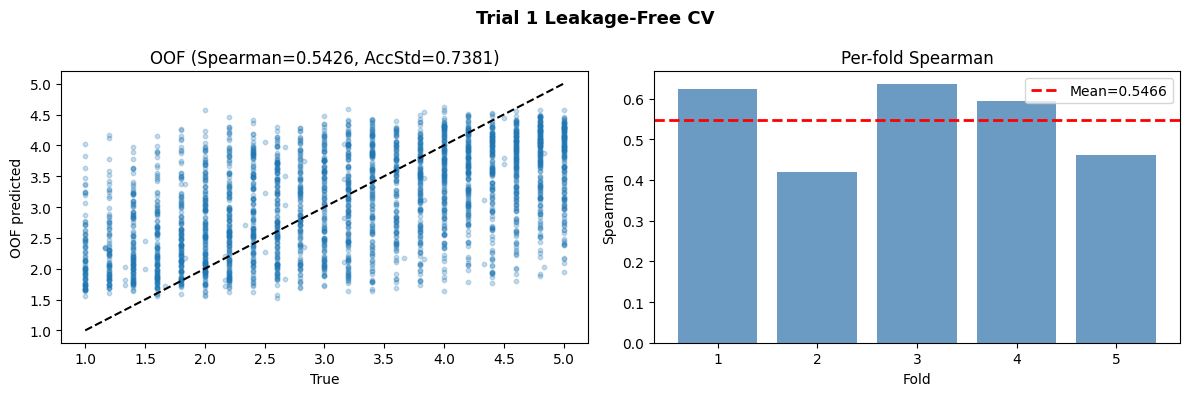

Saved -> trial1_noleak_results.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Trial 1 Leakage-Free CV', fontsize=13, fontweight='bold')

axes[0].scatter(df_cv['average'].values, oof_preds, alpha=0.25, s=10)
axes[0].plot([1, 5], [1, 5], 'k--', lw=1.5)
axes[0].set_xlabel('True')
axes[0].set_ylabel('OOF predicted')
axes[0].set_title(f'OOF (Spearman={oof_sp:.4f}, AccStd={oof_acc:.4f})')

axes[1].bar(range(1, len(spear_folds) + 1), spear_folds, color='steelblue', alpha=0.8)
axes[1].axhline(np.mean(spear_folds), color='red', lw=2, ls='--', label=f'Mean={np.mean(spear_folds):.4f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Spearman')
axes[1].set_title('Per-fold Spearman')
axes[1].legend()

plt.tight_layout()
plt.savefig('trial1_noleak_results.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved -> trial1_noleak_results.png')

In [9]:
from IPython.display import FileLink
FileLink('trial1_models.pt')

/kaggle/working/trial1_models.pt